In [1]:
import glob
import os
from collections.abc import Callable
from pathlib import Path
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.figure import Figure
from PIL import Image
from torch import Tensor

In [2]:
## import pre-built function
from src.torchgeo_p import AGB_Reforest
    

In [3]:
## torchgeo.dataset class
ds = AGB_Reforest(
    root='dataset' ## local path to the dataset download from torchgeo
    )


In [4]:
ds.__len__() ## num patches

100

In [10]:
sample = ds.__getitem__(40).keys()

In [11]:
'prediction_bbox_xyxy' in sample

False

In [17]:
ds.index

AttributeError: 'AGB_Reforest' object has no attribute 'index'

In [19]:
ds.files[10]

'dataset/tiles/Carlos Vera Arteaga RGB/Carlos Vera Arteaga RGB_4_3800_0_7800_4000.png'

In [21]:
dff.head()

,img_path,xmin,ymin,xmax,ymax,score,img_name,tile_index,tile_xmin,tile_ymin,...,is_musacea_g,site,X_g,Y_g,updated diameter,group,updated height,AGB,carbon,id
0,Carlos Vera Guevara RGB_3_0_8305_4000_12305.png,3332.557861,19.092411,3661.390137,364.616425,0.531211,Carlos Vera Guevara RGB,3,0,8305,...,1.0,Carlos Vera Guevara RGB,5298.555843,7709.844671,10.281385,banana,0.0,4.293300,1.674387,30
1,Carlos Vera Guevara RGB_3_0_8305_4000_12305.png,3162.579834,2148.233398,3431.632324,2379.467041,0.511510,Carlos Vera Guevara RGB,3,0,8305,...,1.0,Carlos Vera Guevara RGB,5315.345160,8606.745732,13.528139,banana,0.0,7.702971,3.004159,112
2,Carlos Vera Guevara RGB_3_0_8305_4000_12305.png,2893.605713,244.011108,3095.620605,451.257812,0.251310,Carlos Vera Guevara RGB,3,0,8305,...,1.0,Carlos Vera Guevara RGB,5228.142461,7935.770200,12.732366,banana,0.0,6.769828,2.640233,179
3,Carlos Vera Guevara RGB_3_0_8305_4000_12305.png,2595.111084,1703.712402,2765.227295,1865.253418,0.217742,Carlos Vera Guevara RGB,3,0,8305,...,1.0,Carlos Vera Guevara RGB,4434.058601,8354.081799,9.867583,banana,0.0,3.933601,1.534104,93
4,Carlos Vera Guevara RGB_10_7600_7600_11600_116...,249.691879,123.626862,439.557648,302.768402,0.282849,Carlos Vera Guevara RGB,10,7600,7600,...,1.0,Carlos Vera Guevara RGB,8257.952942,7554.538338,17.825312,banana,0.0,13.862143,5.406236,162


In [25]:
pathfile.name

'Carlos Vera Arteaga RGB_4_3800_0_7800_4000.png'

In [53]:
df_metadata = pd.read_csv("/home/camarada/Documents/CDE/3-semester/DeepLearning/ReforesTree/dataset/mapping/final_dataset.csv")

## random patch
pathfile = Path(ds.files[10])

dff = df_metadata.loc[df_metadata['img_path']== pathfile.name]
dff[['X_g','Y_g']].values

array([[7299.7697809 , 4169.23058643],
       [7996.35886862, 2127.397601  ],
       [6971.71615643, 2803.84947177],
       [8226.54549461, 2103.2226906 ],
       [7795.67230616, 3920.90858051],
       [8167.43770332, 3013.51390207],
       [6665.73374717, 3277.32121927],
       [6754.12627288, 4194.85376335],
       [6733.3470312 , 4550.01327653],
       [7648.817976  , 3420.25398445],
       [7621.14820861, 2326.81276053],
       [7024.2564152 , 3260.72185682],
       [6574.2189521 , 4593.23846195],
       [8456.83978499, 2016.32669929],
       [7963.19821345, 3939.06761459],
       [8304.06390931, 2933.19081267],
       [7119.97012452, 3935.05703037],
       [7475.58585198, 2996.91453963],
       [6572.81931402, 2835.04290455],
       [7233.34080601, 3180.28736231],
       [6509.18961529, 4210.67328997],
       [7249.05981795, 3349.06611465],
       [7196.95021692, 3537.34076248],
       [7451.79200534, 3136.28234107],
       [5991.75419711, 2685.42583234],
       [6229.80032899, 32

In [31]:
dff = pd.read_csv("/home/camarada/Documents/CDE/3-semester/DeepLearning/ReforesTree/dataset/mapping/final_dataset.csv")
##dff.loc[dff['img_path']=='Carlos Vera Arteaga RGB_4_3800_0_7800_4000.png']

dff.columns

Index(['img_path', 'xmin', 'ymin', 'xmax', 'ymax', 'score', 'img_name',
       'tile_index', 'tile_xmin', 'tile_ymin', 'tile_xmax', 'tile_ymax', 'x',
       'y', 'Xmin', 'Ymin', 'Xmax', 'Ymax', 'X_d', 'Y_d', 'lon_d', 'lat_d',
       'is_musacea_d', 'is_banana', 'ground_index', 'name', 'lat_g', 'lon_g',
       'diameter', 'height', 'year', 'plot_id', 'tree_id', 'is_musacea_g',
       'site', 'X_g', 'Y_g', 'updated diameter', 'group', 'updated height',
       'AGB', 'carbon', 'id'],
      dtype='object')

In [36]:
dff[['X_g', 'Y_g']].values

array([[5298.55584258, 7709.84467073],
       [5315.34516048, 8606.74573173],
       [5228.14246085, 7935.77020027],
       ...,
       [9180.65981031, 8052.28205307],
       [9107.21358   , 7434.89013099],
       [9872.36667034, 7206.4375067 ]], shape=(4663, 2))

In [5]:
ds.files[10]

'dataset/tiles/Carlos Vera Arteaga RGB/Carlos Vera Arteaga RGB_4_3800_0_7800_4000.png'

In [12]:
dff.columns

Index(['img_path', 'xmin', 'ymin', 'xmax', 'ymax', 'score', 'img_name',
       'tile_index', 'tile_xmin', 'tile_ymin', 'tile_xmax', 'tile_ymax', 'x',
       'y', 'Xmin', 'Ymin', 'Xmax', 'Ymax', 'X', 'Y', 'lon', 'lat'],
      dtype='object')

Total boxes processed: 120


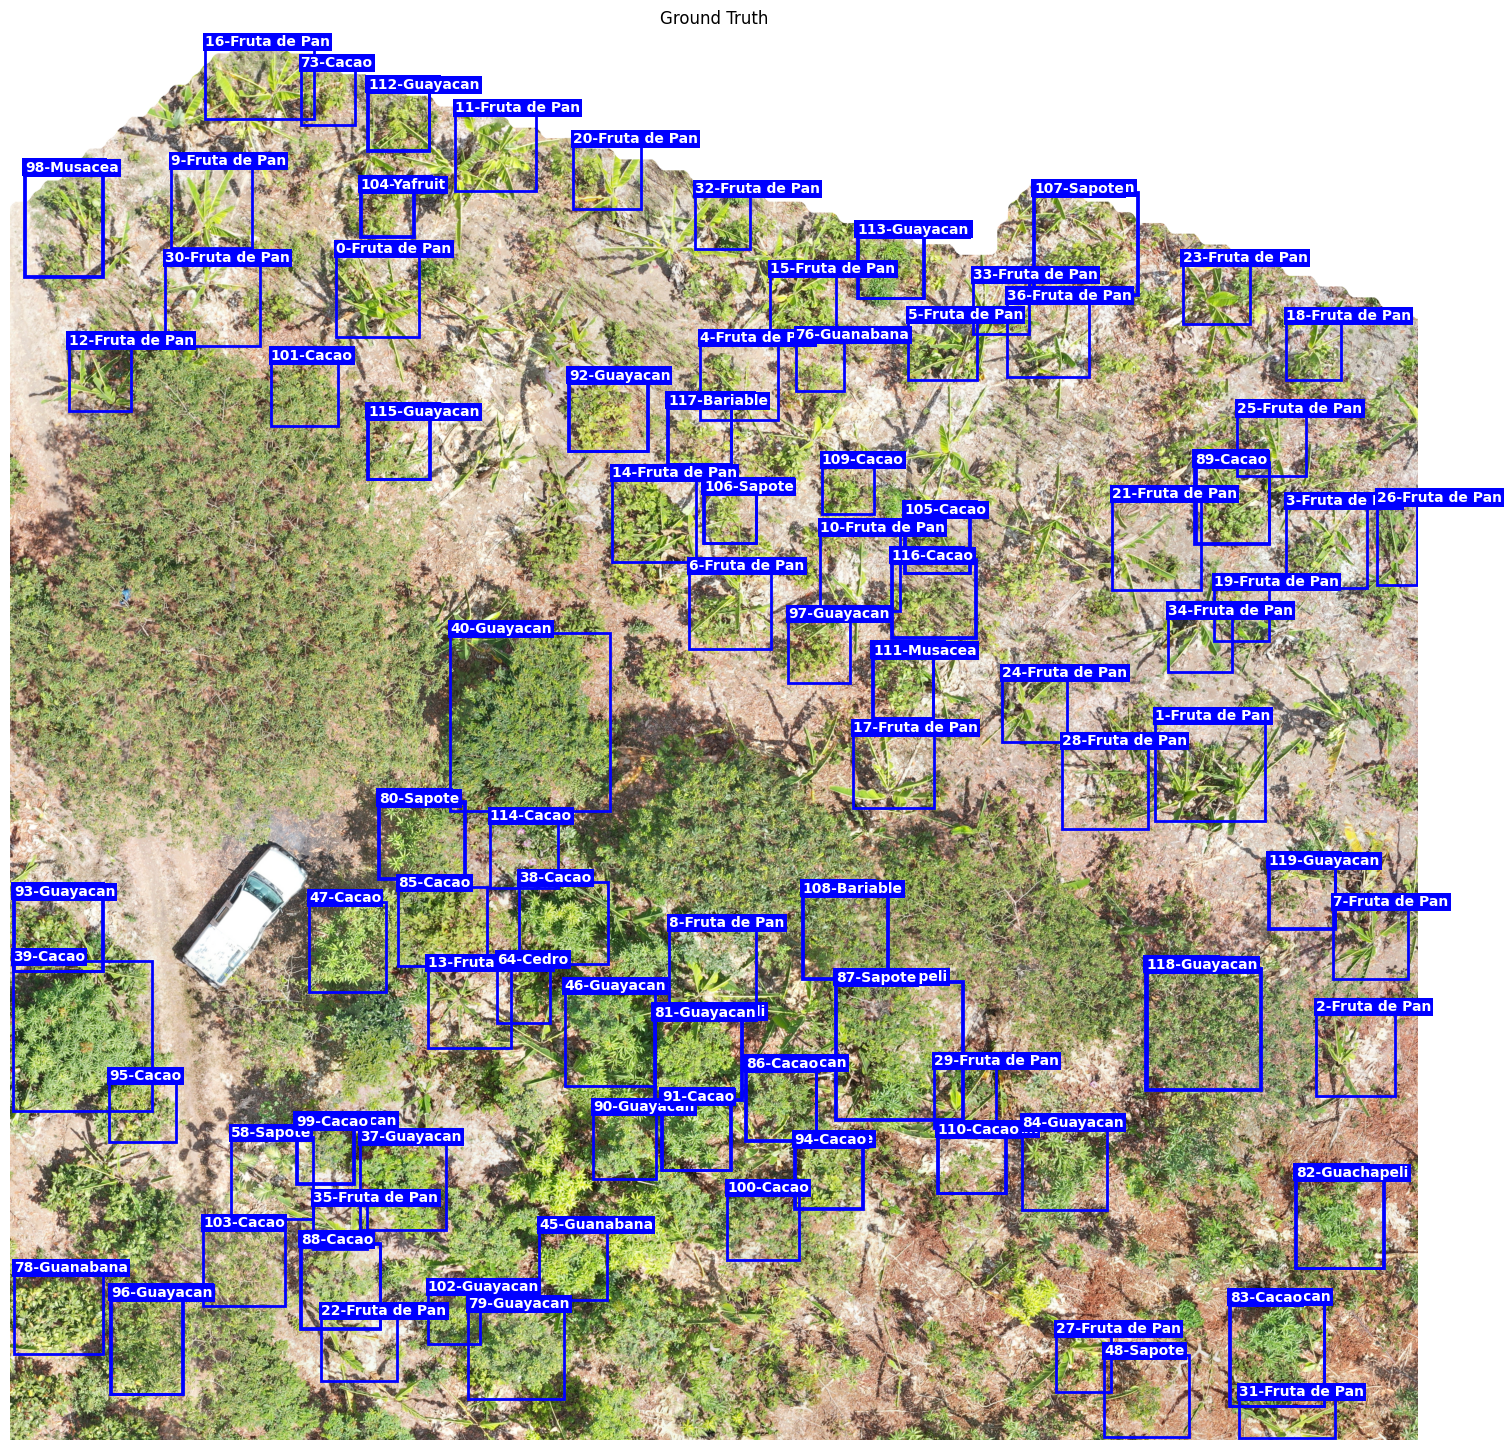

In [6]:
fig = ds.plot2(ds.__getitem__(25),
                figsize=(15,15),
                name_or_group = 'name',
                color='blue')

In [ ]:
sample = ds.__getitem__(25)
labels_name = ds.classes_name[sample['label_name'].numpy()]

array(['Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan',
       'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan',
       'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan',
       'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan',
       'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan',
       'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan',
       'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan',
       'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan',
       'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan', 'Fruta de Pan',
       'Fruta de Pan', 'Guayacan', 'Cacao', 'Cacao', 'Guayacan', 'Cacao',
       'Guachapeli', 'Cacao', 'Guayacan', 'Guanabana', 'Guayacan',
       'Cacao', 'Sapote', 'Guayacan', 'Guachapeli', 'Cacao', 'Cacao',
       'Cacao', 'Guayacan', 'Bariable', 'Sapote', 'Guayacan', 'Sapote',
       'Sapote', 'Guayacan', 'Cedro', 'Cacao', 'Pachaco', 'Cedro',
       'Gua

In [57]:
pathfile

PosixPath('dataset/tiles/Carlos Vera Guevara RGB/Carlos Vera Guevara RGB_4_3800_0_7800_4000.png')

In [65]:
points_list[0]

array([5475.09806394, 2988.42034649])

In [69]:
df_metadata.loc[df_metadata['img_path']== pathfile.name].head()[:2]

,img_path,xmin,ymin,xmax,ymax,score,img_name,tile_index,tile_xmin,tile_ymin,...,is_musacea_g,site,X_g,Y_g,updated diameter,group,updated height,AGB,carbon,id
133,Carlos Vera Guevara RGB_4_3800_0_7800_4000.png,926.831116,626.668152,1160.986572,866.145752,0.505999,Carlos Vera Guevara RGB,4,3800,0,...,1.0,Carlos Vera Guevara RGB,5475.098064,2988.420346,16.392921,banana,0.0,11.596829,4.522763,141
134,Carlos Vera Guevara RGB_4_3800_0_7800_4000.png,3253.311523,1954.481689,3566.140381,2241.173584,0.409928,Carlos Vera Guevara RGB,4,3800,0,...,1.0,Carlos Vera Guevara RGB,6856.401036,4288.633415,18.398268,banana,0.0,14.828464,5.783101,106


In [ ]:
import pyproj

ortho_data = pd.read_csv('dataset/tiles/ortho_data.csv')

def convert_lonlat_to_xy_proj(name, lon, lat, ortho_data):
    """
    Converts lon, lat to x, y position in the tile (origin (0,0) at the top-left of the tile)
    """
    row = ortho_data[ortho_data.name == name]
    X, Y = lonlat_to_xy(lon, lat)
    lon0, lat0 = row.lon_min.values[0], row.lat_max.values[0]
    x0, y0 = lonlat_to_xy(lon0, lat0)

    x = X - x0
    y = Y - y0
    return ([x, y])

def lonlat_to_xy(lon, lat):
    proj_latlon = pyproj.Proj(proj='latlong', datum='WGS84')
    proj_xy = pyproj.Proj(proj="utm", zone=17, datum='WGS84')
    xy = pyproj.transform(proj_latlon, proj_xy, lon, lat)
    return xy[0], xy[1]

def xy_to_lonlat(x, y):
    proj_latlon = pyproj.Proj(proj='latlong', datum='WGS84')
    proj_xy = pyproj.Proj(proj="utm", zone=17, datum='WGS84')
    lonlat = pyproj.transform(proj_xy, proj_latlon, x, y)
    return lonlat[0], lonlat[1]

def convert_xy_to_lonlat_proj(name, tile_xmin, tile_ymin, x, y, ortho_data):
    row = ortho_data[ortho_data.name == name]
    
    # 1. Get the origin in UTM (meters)
    lon0, lat0 = row.lon_min.values[0], row.lat_max.values[0]
    x0, y0 = lonlat_to_xy(lon0, lat0)

    # 2. Get the GSD (meters per pixel)
    # Note: Check if your 'ratio' columns are in meters or degrees. 
    # If they are very small (10^-8), they are degrees. 
    # You should use the meter-based scale factor here.
    gsd_x = row.ratio_x.values[0] 
    gsd_y = row.ratio_y.values[0]

    # 3. Convert PIXEL distance to METER distance before adding
    # X_meters = (pixel_offset + local_pixel) * meters_per_pixel
    X = x0 + (tile_xmin + x) * gsd_x
    Y = y0 - (tile_ymin + y) * gsd_y  # Y usually decreases as you move down in UTM

    lon, lat = xy_to_lonlat(X, Y)
    return ([lon, lat])

In [78]:
ortho_data.name.unique()

array(['Leonor Aspiazu RGB', 'Nestor Macias RGB',
       'Carlos Vera Arteaga RGB', 'Flora Pluas RGB',
       'Carlos Vera Guevara RGB', 'Manuel Macias RGB'], dtype=object)

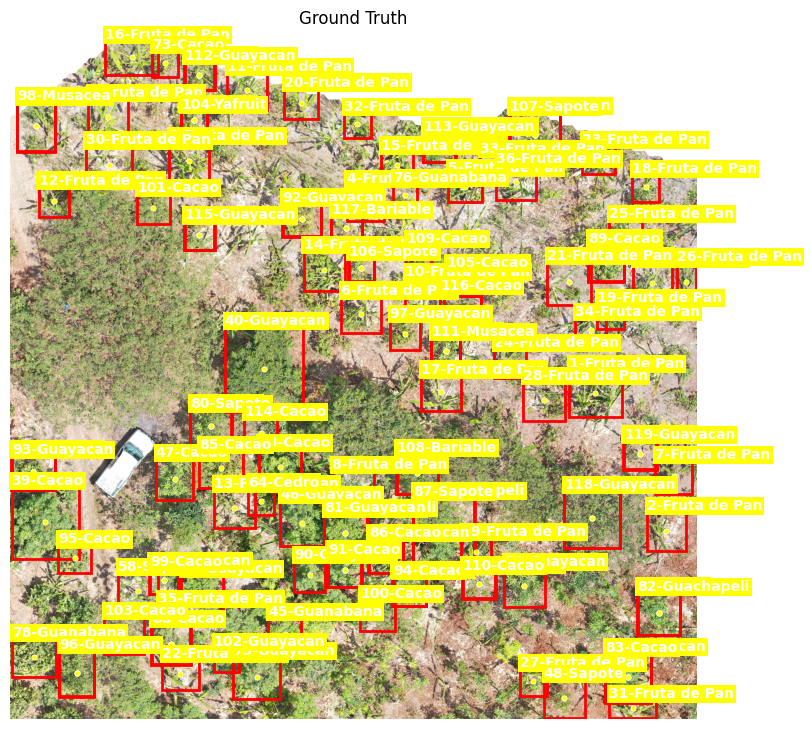

In [82]:
num_patch = 25
sample = ds.__getitem__(num_patch)
labels_name = ds.classes_name[sample['label_name'].numpy()]

## retrieve points 

## random patch
pathfile = Path(ds.files[num_patch])
dff = df_metadata.loc[df_metadata['img_path']== pathfile.name]

points_list  = dff[['x', 'y']].values
offset = dff[['tile_xmin','tile_ymin']].values
points = points_list

image = sample['image'].permute((1, 2, 0)).byte().numpy()
figsize = (8, 8)
    

fig, axs = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
ax = np.array([axs]).flatten()


def draw_boxes(ax, boxes, labels=None, color='red'):
    """Draws bounding boxes and optional text labels."""
    for i, bbox in enumerate(boxes):
        # x1, y1, x2, y2 format
        rect = patches.Rectangle(
            (bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1],
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        
        if labels is not None:
            label_text = f"{i}-{labels[i]}"
            ax.text(
                bbox[0], bbox[1], label_text,
                color='white', fontsize=10, fontweight='bold',
                bbox=dict(facecolor=color, edgecolor='none', pad=1.5)
            )

def draw_points(ax, boxes, labels=None, points=None, color='red', size=20):
    """Draws keypoints using a scatter plot for better performance."""
    # array of [x, y] coordinates
    points = np.array(points)
    ax.scatter(points[:, 0], points[:, 1], c=color, s=size, edgecolors='white', linewidths=0.5)
    for i, bbox in enumerate(boxes):
        if labels is not None:
                label_text = f"{i}-{labels[i]}"
                ax.text(
                    bbox[0], bbox[1], label_text,
                    color='white', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor=color, edgecolor='none', pad=1.5)
                )



# Helper to draw on a specific axis
show_titles=True
def draw_on(ax, img, boxes, title, labels_name,
            points,
            color='red'):
    ax.imshow(img)
    ax.axis('off')
    if show_titles:
        ax.set_title(title)
    draw_boxes(ax, boxes, labels_name, color)
    draw_points(ax,
                 points = points,
                 boxes=boxes,
                 labels=labels_name,
                 color='yellow',
                 size=15)

# Plot Ground Truth
draw_on(ax[0], img = image,
        boxes= sample['bbox_xyxy'],
        labels_name = labels_name,
        points = points,
        title = 'Ground Truth')



In [83]:
sample = ds.__getitem__(10)

In [84]:
sample.keys()

dict_keys(['image', 'bbox_xyxy', 'label', 'agb', 'label_name'])

In [86]:
sample['agb'].shape

torch.Size([50])

In [87]:
sample['bbox_xyxy'].shape

torch.Size([50, 4])

In [89]:
sample['image'].shape

torch.Size([3, 4000, 4000])

## ARchitecture

In [ ]:
import torch
import torch.nn as nn
from torchvision.ops import roi_align
from torchvision.models import resnet18, ResNet18_Weights

class AGBVisualRegressor(nn.Module):
    def __init__(self, output_dim=1):
        super().__init__()
        # 1. Feature Extractor (Backbone)
        # We take a pretrained ResNet and remove the final pooling/fc layers
        resnet = resnet18(weights=ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2]) 
        
        # 2. Adaptation layer
        # ResNet18 output has 512 channels. We'll use RoIAlign to get a fixed 7x7 view.
        self.roi_pool_size = 7
        self.feature_dim = 512 
        
        # 3. Final Regression Head
        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim * self.roi_pool_size * self.roi_pool_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 1) # Predicts AGB for ONE tree
        )

    def forward(self, image, bboxes):
        """
        image: [1, 3, 4000, 4000]
        bboxes: [1, N, 4] -> List of [N, 4] for roi_align
        """
        # Step 1: Extract feature map from the whole image
        # Output shape: [1, 512, H/32, W/32] (for ResNet18)
        feature_map = self.backbone(image)
        
        # Step 2: Crop features based on bboxes
        # roi_align expects a list of tensors, one for each image in the batch
        # We also need to scale coordinates because the feature map is smaller than the image
        spatial_scale = feature_map.shape[-1] / image.shape[-1]
        
        # tree_features shape: [N, 512, 7, 7]
        tree_features = roi_align(feature_map, list(bboxes), 
                                  output_size=(self.roi_pool_size, self.roi_pool_size),
                                  spatial_scale=spatial_scale)
        
        # Step 3: Predict AGB for each tree
        tree_features = tree_features.view(tree_features.size(0), -1)
        individual_agb = self.regressor(tree_features) # [N, 1]
        
        # Step 4: Sum the AGB for the entire patch
        total_patch_agb = torch.sum(individual_agb)
        
        return total_patch_agb